Step_1: Model Setup: Preliminary Step for Generating APSIM Files for All Simulation Scenarios

In [8]:
import json
import os
import pandas as pd
import subprocess

# Main paths and files
apsim_exe = r"C:\Program Files\APSIM2025.4.7727.0\bin\Models.exe"
output_dir = r"C:\Users\Amine\workspace\morocco_maize\APSIM tout les code et figure\apsim calibration\output_simulation_files"
apsim_template = r"C:\Users\Amine\workspace\morocco_maize\APSIM tout les code et figure\apsim calibration\input_calibration\APSIM_Maize_base_model.apsimx"  # Complete base model
soil_csv_file = r"C:\Users\Amine\workspace\morocco_maize\APSIM tout les code et figure\apsim calibration\input_calibration\24inputs.csv"  # Input data
irrigation_csv_file = r"C:\Users\Amine\workspace\morocco_maize\APSIM tout les code et figure\apsim calibration\input_calibration\A24 irrigation.csv"  # Irrigation data



# Load data from CSV files
soil_param_data = pd.read_csv(soil_csv_file, sep=";", dtype=str)
irrigation_data = pd.read_csv(irrigation_csv_file, sep=";", dtype=str)

# Clean column names (in case there are invisible spaces)
soil_param_data.columns = soil_param_data.columns.str.strip()
irrigation_data.columns = irrigation_data.columns.str.strip()

# List of simulations to generate
simulation_names = soil_param_data["simulation"].unique()  # Define simulation_names from CSV data

# Iterating through the simulations
def replace_irrigation_schedule(apsim_model, irrigation_schedule):
    """
    Remplace les événements d'irrigation dans le modèle APSIM en utilisant les données d'un calendrier.
    """
    for simulation in apsim_model.get('Children', []):
        if simulation.get('$type') == "Models.Core.Simulation, Models":
            for zone in simulation.get('Children', []):
                if zone.get('$type') == "Models.Core.Zone, Models":
                    # Rechercher le gestionnaire d'irrigation "Applyirrigation"
                    for manager in zone.get('Children', []):
                        if manager.get('$type') == "Models.Operations, Models" and manager.get('Name') == "Applyirrigation":
                            # Construire la liste des événements d'irrigation
                            irrigation_events = []
                            for entry in irrigation_schedule:
                                date, amount = entry.split(",")  # Séparer la date et la quantité
                                irrigation_events.append({
                                    "$type": "Models.Operation, Models",
                                    "Enabled": True,
                                    "Date": date,
                                    "Action": f"[Irrigation].Apply(amount: {amount}, depth: 750, efficiency: 1.0);",
                                    "Line": f"{date} [Irrigation].Apply(amount: {amount}, depth: 750, efficiency: 1.0);"
                                })
                            # Remplacer la liste des opérations d'irrigation
                            manager["OperationsList"] = irrigation_events
                            # print(f"Calendrier d'irrigation remplacé par {len(irrigation_events)} événements.")
    return apsim_model


def replace_FERT_parameters(apsim_model, sim_params):
    for simulation in apsim_model.get('Children', []):
        if simulation.get('$type') == "Models.Core.Simulation, Models":
            for zone in simulation.get('Children', []):
                if zone.get('$type') == "Models.Core.Zone, Models":
                    # Replace the simulation-specific parameters in the manager
                    for manager in zone.get('Children', []):
                        if manager.get('$type') == "Models.Manager, Models" and manager.get('Name') == "Fertilise at sowing":
                            # Replace simulation parameters
                            for key in ['FertiliserType', 'Amount']:
                                if key in sim_params:
                                    new_value = sim_params[key]
                                    # print(f"Replacing {key} with {new_value}")
                                    
                                    # Replace the parameters in the manager's Parameters section
                                    key_found = False
                                    for param in manager.get('Parameters', []):
                                        if param.get('Key') == key:
                                            param['Value'] = new_value
                                            key_found = True
                                            break
                                    
                                    if not key_found:
                                        pass
                                        # print(f"The parameter {key} was not found in the manager's Parameters.")
                                    else:
                                        pass
                                        # print(f"The parameter {key} was successfully replaced.")
    return apsim_model

def replace_FERT1_parameters(apsim_model, sim_params):
    # Map CSV keys (e.g., FertiliserType_1, Amount_1) to APSIM keys
    mapped_params = {
        "FertiliserType": sim_params.get("FertiliserType_1", ""),
        "Amount": sim_params.get("Amount_1", "")
    }
    
    for simulation in apsim_model.get('Children', []):
        if simulation.get('$type') == "Models.Core.Simulation, Models":
            for zone in simulation.get('Children', []):
                if zone.get('$type') == "Models.Core.Zone, Models":
                    # Replace the simulation-specific parameters in the manager
                    for manager in zone.get('Children', []):
                        if manager.get('$type') == "Models.Manager, Models" and manager.get('Name') == "Fertilise at sowing1":
                            # Replace simulation parameters
                            for key, new_value in mapped_params.items():
                                if new_value:  # Only proceed if the value is not empty
                                    # print(f"Replacing {key} with {new_value}")
                                    
                                    # Replace the parameters in the manager's Parameters section
                                    key_found = False
                                    for param in manager.get('Parameters', []):
                                        if param.get('Key') == key:
                                            param['Value'] = new_value
                                            key_found = True
                                            break
                                    
                                    if not key_found:
                                        pass
                                        # print(f"The parameter {key} was not found in the manager's Parameters.")
                                    else:
                                        pass
                                        # print(f"The parameter {key} was successfully replaced.")
    return apsim_model

def replace_FERTOP_2_parameters(apsim_model, sim_params):
    for simulation in apsim_model.get('Children', []):
        if simulation.get('$type') == "Models.Core.Simulation, Models":
            for zone in simulation.get('Children', []):
                if zone.get('$type') == "Models.Core.Zone, Models":
                    # Replace the simulation-specific parameters in the manager
                    for manager in zone.get('Children', []):
                        if manager.get('$type') == "Models.Manager, Models" and manager.get('Name') == "Fertilise topup":
                            # Replace simulation parameters
                            for csv_key, json_key in [('FertiliserType_2', 'FertiliserType'), ('Threshold-2', 'Threshold')]:
                                if csv_key in sim_params:
                                    new_value = sim_params[csv_key]
                                    # print(f"Replacing {json_key} with {new_value} (from {csv_key})")
                                    
                                    # Replace the parameters in the manager's Parameters section
                                    key_found = False
                                    for param in manager.get('Parameters', []):
                                        if param.get('Key') == json_key:
                                            param['Value'] = new_value
                                            key_found = True
                                            break
                                    
                                    if not key_found:
                                        pass
                                        # print(f"The parameter {json_key} was not found in the manager's Parameters.")
                                    else:
                                        pass
                                        # print(f"The parameter {json_key} was successfully replaced.")
    return apsim_model

def replace_FERTOP_3_parameters(apsim_model, sim_params):
    # Map CSV keys to JSON keys
    mapped_params = {
        "FertiliserType": sim_params.get("FertiliserType_3", ""),  # FertiliserType_3 in CSV -> FertiliserType in JSON
        "Threshold": sim_params.get("Threshold_3", "")            # Threshold_3 in CSV -> Threshold in JSON
    }
    
    for simulation in apsim_model.get('Children', []):
        if simulation.get('$type') == "Models.Core.Simulation, Models":
            for zone in simulation.get('Children', []):
                if zone.get('$type') == "Models.Core.Zone, Models":
                    # Replace the simulation-specific parameters in the manager
                    for manager in zone.get('Children', []):
                        if manager.get('$type') == "Models.Manager, Models" and manager.get('Name') == "Fertilise topup1":
                            # Replace simulation parameters
                            for json_key, new_value in mapped_params.items():
                                if new_value:  # Only proceed if the value is not empty
                                    # print(f"Replacing {json_key} with {new_value} (from corresponding CSV key)")
                                    
                                    # Replace the parameters in the manager's Parameters section
                                    key_found = False
                                    for param in manager.get('Parameters', []):
                                        if param.get('Key') == json_key:
                                            param['Value'] = new_value
                                            key_found = True
                                            break
                                    
                                    if not key_found:
                                        pass
                                        # print(f"The parameter {json_key} was not found in the manager's Parameters.")
                                    else:
                                        pass
                                        # print(f"The parameter {json_key} was successfully replaced.")
    return apsim_model



def replace_simulation_parameters(apsim_model, sim_params):
    """Replace simulation parameters (sowing, cultivar, etc.)."""
    for simulation in apsim_model.get('Children', []):
        if simulation.get('$type') == "Models.Core.Simulation, Models":
            for zone in simulation.get('Children', []):
                if zone.get('$type') == "Models.Core.Zone, Models":
                    for manager in zone.get('Children', []):
                        if manager.get('$type') == "Models.Manager, Models" and manager.get('Name') == "Sow on a fixed date":
                            for key in ['SowDate', 'CultivarName', 'RowSpacing', 'Population']:
                                if key in sim_params:
                                    new_value = sim_params[key]
                                    # print(f"Replacing {key} with {new_value}")
                                    key_found = False
                                    for param in manager.get('Parameters', []):
                                        if param.get('Key') == key:
                                            param['Value'] = new_value
                                            key_found = True
                                            break
                                    if not key_found:
                                        pass
                                        # print(f"The parameter {key} was not found in the manager's Parameters.")
                                    else:
                                        pass
                                        # print(f"The parameter {key} was successfully replaced.")
    return apsim_model

def replace_chemical_parameters(apsim_model, sim_params):
    """Replace soil chemical parameters (pH, EC, CEC)."""
    for simulation in apsim_model.get('Children', []):
        if simulation.get('$type') == "Models.Core.Simulation, Models":
            for zone in simulation.get('Children', []):
                if zone.get('$type') == "Models.Core.Zone, Models":
                    for soil in zone.get('Children', []):
                        if soil.get('$type') == "Models.Soils.Soil, Models":
                            for chemical in soil.get('Children', []):
                                if chemical.get('$type') == "Models.Soils.Chemical, Models":
                                    for key in ['PH', 'EC', 'CEC']:
                                        for i in range(1, 4):
                                            param_key = f"{key}_{i}"
                                            if param_key in sim_params:
                                                new_value = sim_params[param_key]
                                                # print(f"Replacing {param_key} with {new_value}")
                                                chemical[key][i - 1] = float(new_value)
                                    for key in ['PH', 'EC', 'CEC']:
                                        param_key_no_suffix = key
                                        if param_key_no_suffix in sim_params:
                                            new_value = sim_params[param_key_no_suffix]
                                            # print(f"Replacing {param_key_no_suffix} with {new_value}")
                                            chemical[key] = [float(new_value)] * 3
    return apsim_model

def replace_nutr_parameters(apsim_model, sim_params):
    """Replace soil chemical parameters (NO3, NH4, Urea)."""
    for simulation in apsim_model.get('Children', []):
        if simulation.get('$type') == "Models.Core.Simulation, Models":
            for zone in simulation.get('Children', []):
                if zone.get('$type') == "Models.Core.Zone, Models":
                    for soil in zone.get('Children', []):
                        if soil.get('$type') == "Models.Soils.Soil, Models":
                            for nutr in soil.get('Children', []):
                                if nutr.get('$type') == "Models.Soils.Solute, Models":
                                    # Check the name of the chemical substance
                                    name = nutr.get('Name')
                                    
                                    if name == "NO3":
                                        # Check the 3 parameters for NO3
                                        for i in range(1, 4):
                                            param_key = f"NO3_{i}"
                                            if param_key in sim_params:
                                                new_value = sim_params[param_key]
                                                # print(f"Replacing {param_key} with {new_value}")
                                                nutr['InitialValues'][i - 1] = float(new_value)
                                    elif name == "NH4":
                                        # Check the 3 parameters for NH4
                                        for i in range(1, 4):
                                            param_key = f"NH4_{i}"
                                            if param_key in sim_params:
                                                new_value = sim_params[param_key]
                                                # print(f"Replacing {param_key} with {new_value}")
                                                nutr['InitialValues'][i - 1] = float(new_value)
                                    elif name == "Urea":
                                        # Check the 3 parameters for Urea
                                        for i in range(1, 4):
                                            param_key = f"Urea_{i}"
                                            if param_key in sim_params:
                                                new_value = sim_params[param_key]
                                                # print(f"Replacing {param_key} with {new_value}")
                                                nutr['InitialValues'][i - 1] = float(new_value)
    
    return apsim_model

def replace_water_parameters(apsim_model, sim_params):
    """Replace soil water parameters (Water_1, Water_2, Water_3)."""
    for simulation in apsim_model.get('Children', []):
        if simulation.get('$type') == "Models.Core.Simulation, Models":
            for zone in simulation.get('Children', []):
                if zone.get('$type') == "Models.Core.Zone, Models":
                    for soil in zone.get('Children', []):
                        if soil.get('$type') == "Models.Soils.Soil, Models":
                            for water in soil.get('Children', []):
                                if water.get('$type') == "Models.Soils.Water, Models":
                                    # Replace the initial values for the 3 layers
                                    for i in range(1, 4):
                                        param_key = f"Water_{i}"  # Water_1, Water_2, Water_3
                                        if param_key in sim_params:
                                            new_value = sim_params[param_key]
                                            # print(f"Replacing {param_key} with {new_value}")
                                            # Replace the InitialValues for the corresponding layer
                                            water['InitialValues'][i - 1] = float(new_value)
    
    return apsim_model

def replace_physical_parameters(apsim_model, sim_params):
    """Replace the soil physical parameters (BD, DUL, LL15, SAT)."""
    for simulation in apsim_model.get('Children', []):
        if simulation.get('$type') == "Models.Core.Simulation, Models":
            for zone in simulation.get('Children', []):
                if zone.get('$type') == "Models.Core.Zone, Models":
                    for soil in zone.get('Children', []):
                        if soil.get('$type') == "Models.Soils.Soil, Models":
                            for physical in soil.get('Children', []):
                                if physical.get('$type') == "Models.Soils.Physical, Models":
                                    for key in ['Thickness', 'ParticleSizeSand', 'ParticleSizeSilt', 'ParticleSizeClay', 'BD', 'LL15', 'DUL', 'SAT']:
                                        for i in range(1, 4):
                                            param_key = f"{key}_{i}"
                                            if param_key in sim_params:
                                                new_value = sim_params[param_key]
                                                # print(f"Remplacement de {param_key} par {new_value}")
                                                physical[key][i - 1] = float(new_value)
                                    for key in ['Thickness', 'ParticleSizeSand', 'ParticleSizeSilt', 'ParticleSizeClay', 'BD', 'LL15', 'DUL', 'SAT']:
                                        param_key_no_suffix = key
                                        if param_key_no_suffix in sim_params:
                                            new_value = sim_params[param_key_no_suffix]
                                            # print(f"Remplacement de {param_key_no_suffix} par {new_value}")
                                            physical[key] = [float(new_value)] * 3
    return apsim_model

#partia li zedt debut
def replace_Org_parameters(apsim_model, sim_params):
    # Parcourir la structure JSON pour trouver les objets SurfaceOrganicMatter
    for simulation in apsim_model.get('Children', []):
        if simulation.get('$type') == "Models.Core.Simulation, Models":
            for zone in simulation.get('Children', []):
                if zone.get('$type') == "Models.Core.Zone, Models":
                    # Remplacer les paramètres dans chaque SurfaceOrganicMatter
                    for surface_om in zone.get('Children', []):
                        if surface_om.get('$type') == "Models.Surface.SurfaceOrganicMatter, Models" and surface_om.get('Name') == "SurfaceOrganicMatter":
                            # Remplacer les valeurs directement dans l'objet SurfaceOrganicMatter
                            for key in ['InitialResidueMass', 'InitialStandingFraction', 'InitialCNR', 'InitialResidueName']:
                                if key in sim_params:
                                    new_value = sim_params[key]
                                    # print(f"Replacing {key} with {new_value}")
                                    
                                    # Remplacer directement la valeur dans l'objet SurfaceOrganicMatter
                                    if key in surface_om:
                                        surface_om[key] = new_value
                                    else:
                                        pass
                                        # print(f"The parameter {key} was not found in the SurfaceOrganicMatter object.")
    return apsim_model
#partia li zedt fin

def replace_Org_parameters2(apsim_model, sim_params):
    """Replace the soil organic parameters (FOMCNRatio, Carbon, SoilCNRatio, Fbiom, FInert, FOM) based on CSV column names."""
    for simulation in apsim_model.get('Children', []):
        if simulation.get('$type') == "Models.Core.Simulation, Models":
            for zone in simulation.get('Children', []):
                if zone.get('$type') == "Models.Core.Zone, Models":
                    for soil in zone.get('Children', []):
                        if soil.get('$type') == "Models.Soils.Soil, Models":
                            for organic in soil.get('Children', []):
                                if organic.get('$type') == "Models.Soils.Organic, Models" and organic.get('Name') == "Organic":
                                    # Vérifier et remplacer FOMCNRatio
                                    if 'FOMCNRatio' in sim_params:
                                        new_value = float(sim_params['FOMCNRatio'])  # Convertir en float
                                        # print(f"Remplacement de FOMCNRatio par {new_value}")
                                        organic['FOMCNRatio'] = new_value  # Remplacer la valeur dans l'objet

                                    # Remplacer les paramètres avec suffixes (par exemple, Carbon_1, Carbon_2, etc.)
                                    for key in ['Carbon', 'SoilCNRatio', 'FBiom', 'FInert', 'FOM']:
                                        for i in range(1, 4):  # Pour les indices 1 à 3 (par exemple, Carbon_1, Carbon_2, Carbon_3)
                                            param_key = f"{key}_{i}"
                                            if param_key in sim_params:
                                                new_value = float(sim_params[param_key])  # Convertir en float
                                                # print(f"Remplacement de {param_key} par {new_value}")
                                                # Remplacer les valeurs dans les listes de `organic`
                                                if key in organic:
                                                    organic[key][i-1] = new_value  # Remplacer la valeur de la liste (index 0, 1, 2)
                                                
    return apsim_model


# Function to apply simulation dates
def replace_simulation_dates(apsim_model, sim_params):
    """Apply start and end dates from the CSV."""
    start_date = sim_params["Start"]
    end_date = sim_params["End"]
    for child in apsim_model['Children']:
        if child['$type'] == "Models.Core.Simulation, Models":
            for simulation_child in child['Children']:
                if simulation_child['$type'] == "Models.Clock, Models":
                    simulation_child["Start"] = start_date
                    simulation_child["End"] = end_date
                    # print(f"Dates modified for the simulation: Start={start_date}, End={end_date}")
                    break
    return apsim_model

def replace_climate_file(apsim_model, sim_name):

    plots = [
        "V1", "V2", "V3", "V4", "L1", "L2", "L3", "L4", "L5", "L6", "L7", "L8", "L9", "L10", "L11", "L12", "L13", "L14"  
    ]
    if sim_name in plots:
        # print(f"Modifying climate file for {sim_name}")
        # Iterate through the simulations and modify the "Weather" section for the specified plots
        for simulation in apsim_model['Children']:
            if simulation['$type'] == "Models.Core.Simulation, Models":
                for child in simulation['Children']:
                    if child['$type'] == "Models.Climate.Weather, Models":
                        child["FileName"] = r"C:\Users\Amine\workspace\morocco_maize\APSIM tout les code et figure\apsim calibration\input_calibration\climate22.met"  # Replace the climate file path
                        # print(f"Climate file changed for {sim_name}: {child['FileName']}")
    return apsim_model


def replace_climate_filee(apsim_model, sim_name):

    plots = [
        "B1", "B2", "B3", "B4", "B5", "B6", "B7", "B8", "B9"
    ]
    if sim_name in plots:
        # print(f"Modifying climate file for {sim_name}")
        # Iterate through the simulations and modify the "Weather" section for the specified plots
        for simulation in apsim_model['Children']:
            if simulation['$type'] == "Models.Core.Simulation, Models":
                for child in simulation['Children']:
                    if child['$type'] == "Models.Climate.Weather, Models":
                        child["FileName"] = r"C:\Users\Amine\workspace\morocco_maize\APSIM tout les code et figure\apsim calibration\input_calibration\climatee24.met" # Replace the climate file path
                        # print(f"Climate file changed for {sim_name}: {child['FileName']}")
    return apsim_model
# Function to modify the APSIM file by applying the replacements
def modify_soil_params(apsim_template, sim_name, sim_params, irrigation_schedule):
    """Apply parameter replacements and irrigation."""
    with open(apsim_template, 'r') as file:
        apsim_model = json.load(file)

    # Apply parameter replacements(SowDate,CultivarName,RowSpacing,Population)
    apsim_model = replace_simulation_parameters(apsim_model, sim_params)
    # replace simulation dates
    apsim_model = replace_simulation_dates(apsim_model, sim_params)
    # replace the irrigation schedule
    apsim_model = replace_irrigation_schedule(apsim_model, irrigation_schedule)
    # replace chemical parameters(pH, EC, CEC)
    apsim_model = replace_chemical_parameters(apsim_model, sim_params)
    # replace NUTR parameters(NO3, NH4, Urea)
    apsim_model = replace_nutr_parameters(apsim_model, sim_params)
    # replace initial water settings(initial water content)
    apsim_model = replace_water_parameters(apsim_model, sim_params)
    # replace physical parameters((BD, DUL, LL15, SAT))
    apsim_model = replace_physical_parameters(apsim_model, sim_params)
    # replace ORG
    apsim_model = replace_Org_parameters(apsim_model, sim_params)
        # replace ORG2
    apsim_model = replace_Org_parameters2(apsim_model, sim_params)
    # replace FERT parameters(Fertilise at sowing and Amount)
    apsim_model = replace_FERT_parameters(apsim_model, sim_params)
    # replace FERT parameters(Fertilise at sowing and Amount1)
    apsim_model = replace_FERT1_parameters(apsim_model, sim_params)

# replace FERTop parameters(Fertilise at sowing and Amount)
    apsim_model = replace_FERTOP_2_parameters(apsim_model, sim_params)
    # replace FERTop1 parameters(Fertilise at sowing and Amount1)
    apsim_model = replace_FERTOP_3_parameters(apsim_model, sim_params)

    # Replace the climate file 
    apsim_model = replace_climate_file(apsim_model, sim_name)
    apsim_model = replace_climate_filee(apsim_model, sim_name)
    # Create the output file with the modified parameters
    output_file = os.path.join(output_dir, f"{sim_name}_modified.apsimx")
    with open(output_file, 'w') as f:
        json.dump(apsim_model, f, indent=4)
    
    # print(f"Fichier APSIMX généré : {output_file}")
    
    return output_file

# Function to run APSIM
def run_apsim(apsim_file):
    cmd = [apsim_exe, apsim_file]
    # print(f"Running APSIM with the command: {' '.join(cmd)}")
    process = subprocess.run(cmd, check=False)
    if process.returncode != 0:
        print(f"Error: APSIM execution failed for {apsim_file}.")
        return False
    # print(f"APSIM simulation completed for {apsim_file}.")
    return True

# Function to read the results from the .db file
def read_results(output_dir, base_name):
    db_file = f"{base_name}.db"
    db_path = os.path.join(output_dir, db_file)

    if not os.path.exists(db_path):
        # print(f"Error: The database file {db_path} cannot be found.")
        return None

    # print(f"Database file found: {db_path}")

    # Read the results
    import sqlite3
    import pandas as pd
    with sqlite3.connect(db_path) as cnx:
        df = pd.read_sql_query("SELECT * FROM Report", cnx)
        # print("Results read successfully.")
        return df


# Main entry point
if __name__ == "__main__":
    for sim_name in simulation_names:  # Iterate over all simulations
        # Filter parameters for this simulation
        sim_params = soil_param_data[soil_param_data["simulation"] == sim_name].iloc[0].to_dict()
        if not sim_params:
            # print(f"No parameters found for simulation {sim_name}.")
            continue
        
        # Extract irrigation schedule for this simulation
        irr_data = irrigation_data[irrigation_data["simulation"] == sim_name]
        irrigation_schedule = []
        for _, row in irr_data.iterrows():
            irrigation_schedule.append(f"{row['date']},{row['irrigation_amount']}")

        # Display extracted parameters for the current simulation
        # print(f"Modifications for simulation {sim_name}:")
        # print(sim_params)
        # print(f"Irrigation data: {irrigation_schedule}")
        
        try:
            # Modify the APSIM file
            apsim_file = modify_soil_params(apsim_template, sim_name, sim_params, irrigation_schedule)
            
            # Step 2: Run APSIM
            if run_apsim(apsim_file):
                # Step 3: Read results
                base_name = os.path.splitext(os.path.basename(apsim_file))[0]
                results = read_results(output_dir, base_name)
                if results is not None:
                    pass
                    # print(f"Results for {sim_name}:")
                    # print(results.head())

        except ValueError as e:
            # print(f"Error modifying APSIMX file for {sim_name}: {e}")
            continue


Step_2: prepare_APSIM_simulation_outputs_maize

In [12]:
import sqlite3
import os
import pandas as pd

def extract_phenology_data_from_db(db_folder_path, output_excel_path):
    """
    Extract data from each SQLite DB file and save to an Excel file.
    Extracted columns:
    - Clock.Today.DayOfYear-Maize.SowingDate.DayOfYear+1
    - Clock.Today
    - Phenology.AccumulatedTT
    - TotalSWC
    - Soil.NO3.ppm(1)
    - Maize.Phenology.CurrentStageName
    - ABGB
    - Maize.Leaf.LAI
    - MineralN
    - MaizeN
    """
    db_files = [f for f in os.listdir(db_folder_path) if f.endswith('.db')]
    all_data = []

    for db_file in db_files:
        db_path = os.path.join(db_folder_path, db_file)

        conn = sqlite3.connect(db_path)
        cursor = conn.cursor()

        # Vérifier si la table Report existe
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
        tables = [table[0] for table in cursor.fetchall()]

        if 'Report' not in tables:
            print(f"Table 'Report' not found in {db_file}. Skipping...")
            conn.close()
            continue

        query = """
        SELECT
            `Clock.Today.DayOfYear-Maize.SowingDate.DayOfYear+1`,
            `Clock.Today`,
            `Phenology.AccumulatedTT`,
            `TotalSWC`,
            `Soil.NO3.ppm(1)`,
            `Maize.Phenology.CurrentStageName`,
            `ABGB`,
            `Maize.Leaf.LAI`,
            `MineralN`,
            `MaizeN`
        FROM Report
        """

        try:
            cursor.execute(query)
            data = cursor.fetchall()
        except Exception as e:
            print(f"Error while reading {db_file}: {e}")
            conn.close()
            continue

        conn.close()

        if data:
            df = pd.DataFrame(data, columns=[
                'Clock.Today.DayOfYear-Maize.SowingDate.DayOfYear+1',
                'Clock.Today',
                'Phenology.AccumulatedTT',
                'TotalSWC',
                'Soil.NO3.ppm(1)',
                'Maize.Phenology.CurrentStageName',
                'ABGB',
                'Maize.Leaf.LAI',
                'MineralN',
                'MaizeN'
            ])

            df['DB File'] = db_file
            all_data.append(df)
        else:
            pass
            # print(f"No relevant data found in {db_file}. Skipping...")

    if all_data:
        final_df = pd.concat(all_data, ignore_index=True)
        final_df.to_excel(output_excel_path, index=False)
        # print(f"Data extracted and saved to: {output_excel_path}")
    # else:
        # print("No data extracted from any DB files.")

# Define paths
db_folder = r"C:\Users\Amine\workspace\morocco_maize\APSIM tout les code et figure\apsim calibration\output_simulation_files"
output_excel = os.path.join(db_folder, "APSIM_simulation_outputs_maize.xlsx")

# Run the extraction function
extract_phenology_data_from_db(db_folder, output_excel)

Step_3: Observed versus simulated maize growth, soil water, and nitrogen variables during APSIM model calibration and validation

C:\Users\Amine\AppData\Local\Temp\ipykernel_7284\2740058074.py:119: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
C:\Users\Amine\AppData\Local\Temp\ipykernel_7284\2740058074.py:119: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
C:\Users\Amine\AppData\Local\Temp\ipykernel_7284\2740058074.py:119: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
C:\Users\Amine\AppData\Local\Temp\ipykernel_7284\2740058074.py:119: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('+').  Matplotlib is ignor

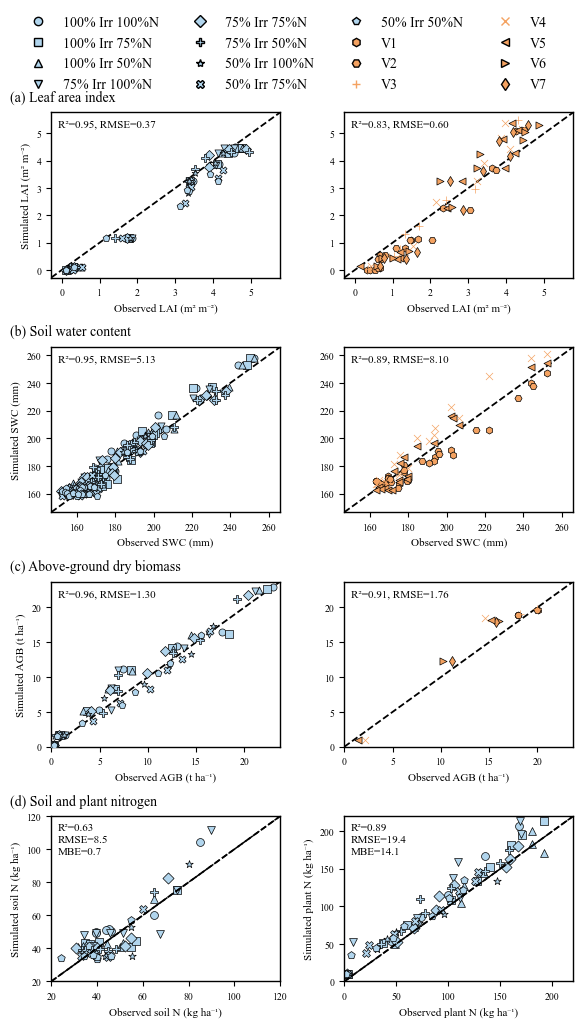

In [14]:
# -*- coding: utf-8 -*-
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.metrics import r2_score, mean_squared_error
from matplotlib.lines import Line2D

# ====================== STYLE GLOBAL ======================

mpl.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "axes.linewidth": 1.0,
})
# ===================== SYMBOLS ======================
CAL_SYMBOLS = ['o', 's', '^', 'v', 'D', 'P', '*', 'X', 'p']
VAL_SYMBOLS = ['h', 'H', '+', 'x', '<', '>', 'd']

# ===================== COULEURS ======================
CAL_FACE = "#B1D5ED"
VAL_FACE = "#F4A261"
UNFILLED_MARKERS = {"+", "x"}

# ===================== ORDRE =====================
CAL_ORDER = [
    "B1_modified.db", "B2_modified.db", "B3_modified.db",
    "B4_modified.db", "B5_modified.db", "B6_modified.db",
    "B7_modified.db", "B8_modified.db", "B9_modified.db"
]
VAL_ORDER = [
    "C2_modified.db", "C3_modified.db", "C5_modified.db",
    "L11_modified.db", "L12_modified.db", "L7_modified.db", "L8_modified.db"
]

CAL_FILES = set(CAL_ORDER)
VAL_FILES = set(VAL_ORDER)

# ====================== LABELS ======================
db_labels = {
    "B1_modified.db": "100% Irr 100%N",
    "B2_modified.db": "100% Irr 75%N",
    "B3_modified.db": "100% Irr 50%N",
    "B4_modified.db": "75% Irr 100%N",
    "B5_modified.db": "75% Irr 75%N",
    "B6_modified.db": "75% Irr 50%N",
    "B7_modified.db": "50% Irr 100%N",
    "B8_modified.db": "50% Irr 75%N",
    "B9_modified.db": "50% Irr 50%N",
    "C2_modified.db": "V1",
    "C3_modified.db": "V2",
    "C5_modified.db": "V3",
    "L11_modified.db": "V4",
    "L12_modified.db": "V5",
    "L7_modified.db": "V6",
    "L8_modified.db": "V7"
}

cal_marker_map = {db: CAL_SYMBOLS[i] for i, db in enumerate(CAL_ORDER)}
val_marker_map = {db: VAL_SYMBOLS[i] for i, db in enumerate(VAL_ORDER)}

# ====================== FICHIERS ======================
SIM_FILE   = r"C:\Users\Amine\workspace\morocco_maize\APSIM tout les code et figure\apsim calibration\output_simulation_files\APSIM_simulation_outputs_maize.xlsx"
OBS_FILE   = r"C:\Users\Amine\workspace\morocco_maize\APSIM tout les code et figure\apsim calibration\input_calibration\24observed data.xlsx"
N_XLSX     = r"C:\Users\Amine\workspace\morocco_maize\APSIM tout les code et figure\apsim calibration\input_calibration\observed_nitrogen_data.xlsx"
OUTPUT_DIR = r"C:\Users\Amine\workspace\morocco_maize\APSIM tout les code et figure\apsim calibration\figure"

# =====================================================
# FONCTION CAL / VAL (LAI, SWC, BIOMASS)
# =====================================================
def plot_var_split(ax_cal, ax_val, obs_df, sim_df, obs_col, sim_col, ylab):

    cal_parts, val_parts = [], []

    for db in obs_df["DB File"].dropna().unique():

        o = obs_df[obs_df["DB File"] == db].copy()
        s = sim_df[sim_df["DB File"] == db].copy()
        if o.empty or s.empty:
            continue

        o["Date"] = pd.to_numeric(o["Date"], errors="coerce")
        s["Clock.Today.DayOfYear-Maize.SowingDate.DayOfYear+1"] = pd.to_numeric(
            s["Clock.Today.DayOfYear-Maize.SowingDate.DayOfYear+1"], errors="coerce"
        )

        m = pd.merge(
            o, s,
            left_on="Date",
            right_on="Clock.Today.DayOfYear-Maize.SowingDate.DayOfYear+1",
            how="inner"
        ).dropna(subset=[obs_col, sim_col])

        if m.empty:
            continue

        if db in CAL_FILES:
            ax = ax_cal
            marker = cal_marker_map[db]
            face = CAL_FACE
            cal_parts.append(m)

        elif db in VAL_FILES:
            ax = ax_val
            marker = val_marker_map[db]
            face = VAL_FACE
            val_parts.append(m)
        else:
            continue

        ax.scatter(
            m[obs_col], m[sim_col],
            s=26,
            marker=marker,
            facecolor=face,
            edgecolor="black",
            linewidth=0.5,
            zorder=3
        )

    def stats(parts):
        if not parts:
            return np.nan, np.nan
        d = pd.concat(parts, ignore_index=True)
        return (
            r2_score(d[obs_col], d[sim_col]),
            np.sqrt(mean_squared_error(d[obs_col], d[sim_col]))
        )

    r2c, rmsec = stats(cal_parts)
    r2v, rmsev = stats(val_parts)

    ax_cal.text(0.03, 0.96, f"R²={r2c:.2f}, RMSE={rmsec:.2f}",
                transform=ax_cal.transAxes, va="top")
    ax_val.text(0.03, 0.96, f"R²={r2v:.2f}, RMSE={rmsev:.2f}",
                transform=ax_val.transAxes, va="top")
    ax_cal.set_ylabel(ylab)

# =====================================================
# OUTILS AZOTE
# =====================================================
def normalize_parcel_name(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    x = x.replace(".db", "")
    x = x.replace("_modified", "")
    return x

def build_parcel_key_from_obs(df_obs):
    df_obs = df_obs.copy()

    if "SimulationName" in df_obs.columns:
        df_obs["ParcelKey"] = df_obs["SimulationName"].apply(normalize_parcel_name)
    elif "DB File" in df_obs.columns:
        df_obs["ParcelKey"] = df_obs["DB File"].apply(normalize_parcel_name)
    else:
        raise ValueError(
            "La feuille d'observation azote doit contenir 'SimulationName' ou 'DB File'."
        )

    return df_obs

def build_parcel_key_from_sim(df_sim):
    df_sim = df_sim.copy()

    if "DB File" not in df_sim.columns:
        raise ValueError("SIM_FILE doit contenir la colonne 'DB File'.")

    df_sim["ParcelKey"] = df_sim["DB File"].apply(normalize_parcel_name)
    return df_sim

def prepare_nitrogen(df_obs, df_sim, obs_col, sim_col):
    obs = build_parcel_key_from_obs(df_obs)
    sim = build_parcel_key_from_sim(df_sim)

    # Dates normalisées au jour pour éviter 00:00:00 vs 12:00:00
    obs["Clock.Today"] = pd.to_datetime(
        obs["Clock.Today"], dayfirst=True, errors="coerce"
    ).dt.normalize()

    sim["Clock.Today"] = pd.to_datetime(
        sim["Clock.Today"], dayfirst=True, errors="coerce"
    ).dt.normalize()

    obs[obs_col] = pd.to_numeric(obs[obs_col], errors="coerce")
    sim[sim_col] = pd.to_numeric(sim[sim_col], errors="coerce")

    obs = obs.dropna(subset=["ParcelKey", "Clock.Today", obs_col])
    sim = sim.dropna(subset=["ParcelKey", "Clock.Today", sim_col])

    merged = obs.merge(
        sim[["ParcelKey", "Clock.Today", sim_col]],
        on=["ParcelKey", "Clock.Today"],
        how="inner"
    ).dropna(subset=[obs_col, sim_col])

    merged = merged.set_index("ParcelKey")
    return merged[obs_col], merged[sim_col]

# =====================================================
# FONCTION AZOTE
# =====================================================
def plot_panel(ax, obs, sim, xlab, ylab, limits):

    x = obs.values.astype(float)
    y = sim.values.astype(float)

    xx = np.linspace(limits[0], limits[1], 200)
    ax.plot(xx, xx, '--', color='black', linewidth=1.1)

    # Affichage B1..B9 comme dans ton script original
    for i, p in enumerate(["B1", "B2", "B3", "B4", "B5", "B6", "B7", "B8", "B9"]):
        mask = obs.index == p
        if mask.any():
            ax.scatter(
                obs[mask], sim[mask],
                marker=CAL_SYMBOLS[i],
                facecolor=CAL_FACE,
                edgecolor='black',
                s=32,
                linewidth=0.5
            )

    if len(x) >= 2:
        ss_res = np.sum((y - x) ** 2)
        ss_tot = np.sum((x - np.mean(x)) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan
        rmse = np.sqrt(np.mean((y - x) ** 2))
        mbe = np.mean(y - x)
        txt = f"R²={r2:.2f}\nRMSE={rmse:.1f}\nMBE={mbe:.1f}"
    else:
        txt = f"n={len(x)}\nR²=NA\nRMSE=NA\nMBE=NA"

    ax.text(0.03, 0.96, txt, transform=ax.transAxes, va="top")

    ax.set_xlim(limits[0], limits[1])
    ax.set_ylim(limits[2], limits[3])
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)

# =====================================================
# DONNÉES NON AZOTE
# =====================================================
sim   = pd.read_excel(SIM_FILE)
lai   = pd.read_excel(OBS_FILE, sheet_name="LAI")
swc   = pd.read_excel(OBS_FILE, sheet_name="SWC")
biom  = pd.read_excel(OBS_FILE, sheet_name="BM")

# =====================================================
# DONNÉES AZOTE
# simulé = SIM_FILE
# observé = N_XLSX
# =====================================================
df_report = pd.read_excel(SIM_FILE)
df_soil   = pd.read_excel(N_XLSX, sheet_name="Feuil1")
df_plant  = pd.read_excel(N_XLSX, sheet_name="F2")

required_sim_cols = {"DB File", "Clock.Today", "MineralN", "MaizeN"}
missing_sim = required_sim_cols - set(df_report.columns)
if missing_sim:
    raise ValueError(f"Colonnes manquantes dans SIM_FILE pour l'azote simulé: {missing_sim}")

required_soil = {"Clock.Today", "observedMineralN"}
required_plant = {"Clock.Today", "observedMaizeN"}

missing_soil = required_soil - set(df_soil.columns)
missing_plant = required_plant - set(df_plant.columns)

if missing_soil:
    raise ValueError(f"Colonnes manquantes dans Feuil1: {missing_soil}")
if missing_plant:
    raise ValueError(f"Colonnes manquantes dans F2: {missing_plant}")

soil_obs, soil_sim   = prepare_nitrogen(df_soil,  df_report, "observedMineralN", "MineralN")
plant_obs, plant_sim = prepare_nitrogen(df_plant, df_report, "observedMaizeN", "MaizeN")

# =====================================================
# FIGURE GLOBALE
# =====================================================
fig, axs = plt.subplots(4, 2, figsize=(6, 11))
fig.subplots_adjust(left=0.11, right=0.98, top=0.87, bottom=0.08,
                    hspace=0.42, wspace=0.28)

row_titles = [
    "(a) Leaf area index",
    "(b) Soil water content",
    "(c) Above-ground dry biomass",
    "(d) Soil and plant nitrogen"
]
for i, title in enumerate(row_titles):
    axs[i, 0].text(-0.18, 1.05, title, transform=axs[i, 0].transAxes,
                   fontsize=10, va="bottom", ha="left")

# --- LAI / SWC / BIOMASS
plot_var_split(axs[0,0], axs[0,1], lai, sim,
               "LAI", "Maize.Leaf.LAI", "Simulated LAI (m² m⁻²)")
plot_var_split(axs[1,0], axs[1,1], swc, sim,
               "SWC_Observed", "TotalSWC", "Simulated SWC (mm)")
plot_var_split(axs[2,0], axs[2,1], biom, sim,
               "Biomass_Observed", "ABGB", "Simulated AGB (t ha⁻¹)")

# --- Fix Biomass padding
pad = 0.7
axs[2,0].set_xlim(0, 23 + pad); axs[2,0].set_ylim(0, 23 + pad)
axs[2,1].set_xlim(0, 23 + pad); axs[2,1].set_ylim(0, 23 + pad)

# --- AZOTE
plot_panel(axs[3,0], soil_obs, soil_sim,
           "Observed values", "Simulated soil N (kg ha⁻¹)",
           (20, 120, 20, 120))
plot_panel(axs[3,1], plant_obs, plant_sim,
           "Observed values", "Simulated plant N (kg ha⁻¹)",
           (0, 220, 0, 220))

# =====================================================
# X-LABEL : "Observed <paramètre> (<unité>)"
# =====================================================
for r in range(axs.shape[0]):

    ylab_left = axs[r, 0].get_ylabel()
    if ylab_left:
        axs[r, 0].set_xlabel(ylab_left.replace("Simulated", "Observed", 1))

    ylab_right = axs[r, 1].get_ylabel()
    if not ylab_right:
        ylab_right = ylab_left
    if ylab_right:
        axs[r, 1].set_xlabel(ylab_right.replace("Simulated", "Observed", 1))

# =====================================================
# MÊMES LIMITES (X et Y) entre gauche/droite POUR LAI, SWC, AGB uniquement
# =====================================================
for r in [0, 1, 2]:
    axL = axs[r, 0]
    axR = axs[r, 1]

    xL0, xL1 = axL.get_xlim(); yL0, yL1 = axL.get_ylim()
    xR0, xR1 = axR.get_xlim(); yR0, yR1 = axR.get_ylim()

    lo = min(xL0, yL0, xR0, yR0)
    hi = max(xL1, yL1, xR1, yR1)

    axL.set_xlim(lo, hi); axL.set_ylim(lo, hi)
    axR.set_xlim(lo, hi); axR.set_ylim(lo, hi)

    axL.plot([lo, hi], [lo, hi], '--', color='black', linewidth=1.3)
    axR.plot([lo, hi], [lo, hi], '--', color='black', linewidth=1.3)

# Azote: juste tracer la 1:1 selon limites fixes
for ax in [axs[3,0], axs[3,1]]:
    lo = min(ax.get_xlim()[0], ax.get_ylim()[0])
    hi = max(ax.get_xlim()[1], ax.get_ylim()[1])
    ax.plot([lo, hi], [lo, hi], '--', color='black', linewidth=1.3)

# =====================================================
# LÉGENDE
# =====================================================
handles = []

for db in CAL_ORDER:
    mk = cal_marker_map[db]
    if mk in UNFILLED_MARKERS:
        handles.append(Line2D([0],[0], marker=mk, linestyle='none',
                              markerfacecolor='none',
                              markeredgecolor=CAL_FACE,
                              color=CAL_FACE,
                              markersize=6, label=db_labels[db]))
    else:
        handles.append(Line2D([0],[0], marker=mk, linestyle='none',
                              markerfacecolor=CAL_FACE,
                              markeredgecolor='black',
                              markersize=6, label=db_labels[db]))

for db in VAL_ORDER:
    mk = val_marker_map[db]
    if mk in UNFILLED_MARKERS:
        handles.append(Line2D([0],[0], marker=mk, linestyle='none',
                              markerfacecolor='none',
                              markeredgecolor=VAL_FACE,
                              color=VAL_FACE,
                              markersize=6, label=db_labels[db]))
    else:
        handles.append(Line2D([0],[0], marker=mk, linestyle='none',
                              markerfacecolor=VAL_FACE,
                              markeredgecolor='black',
                              markersize=6, label=db_labels[db]))

fig.legend(handles, [h.get_label() for h in handles],
           loc="upper center", ncol=4, bbox_to_anchor=(0.5, 0.97),
           frameon=False, fontsize=10)

# =====================================================
# SAUVEGARDE
# =====================================================
os.makedirs(OUTPUT_DIR, exist_ok=True)
save_path = os.path.join(OUTPUT_DIR, "comparison_complete_8panels_FINAL.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

# print("✓ Figure enregistrée :", save_path)

Step_4: APSIM-Maize Time-Series Figures: Temporal Dynamics of LAI, Biomass, and Soil Water Content (SWC)

Leaf area index

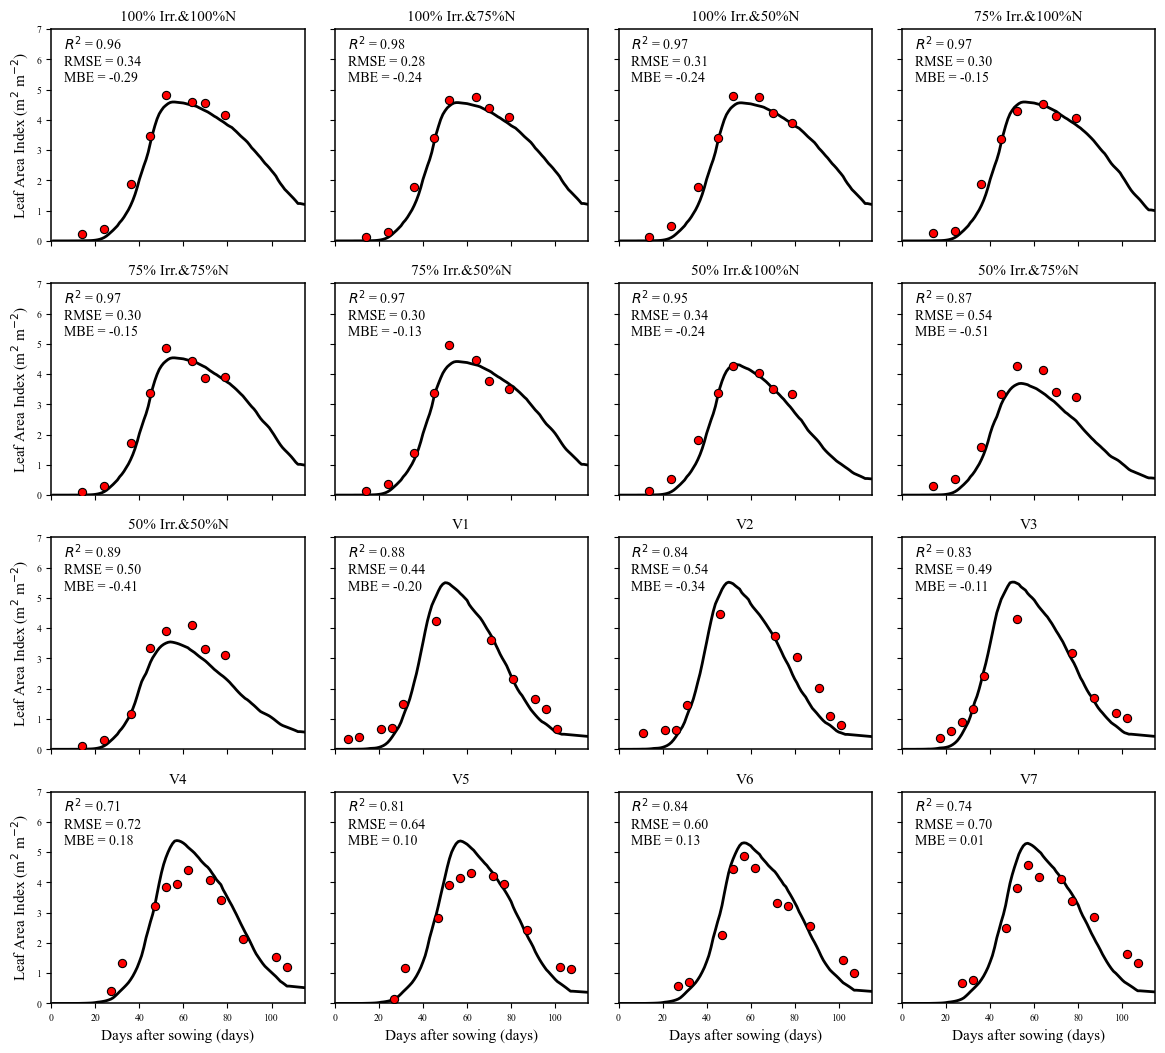

✅ Figure LAI enregistrée : C:\Users\Amine\workspace\morocco_maize\APSIM tout les code et figure\apsim calibration\figure\APSIM_LAI_timeseries_ALL.png


In [15]:
# -*- coding: utf-8 -*-
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.metrics import r2_score, mean_squared_error

# =====================================================
# STYLE GLOBAL (publication)
# =====================================================
mpl.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "axes.linewidth": 1.1,
})

# =====================================================
# CHEMINS
# =====================================================
SIM_FILE = r"C:\Users\Amine\workspace\morocco_maize\APSIM tout les code et figure\apsim calibration\output_simulation_files\APSIM_simulation_outputs_maize.xlsx"
OBS_FILE = r"C:\Users\Amine\workspace\morocco_maize\APSIM tout les code et figure\apsim calibration\input_calibration\24observed data.xlsx"
OUTPUT_DIR = r"C:\Users\Amine\workspace\morocco_maize\APSIM tout les code et figure\apsim calibration\figure"

# =====================================================
# LABELS DES SCÉNARIOS
# =====================================================
db_labels = {
    "B1_modified.db": "100% Irr.&100%N",
    "B2_modified.db": "100% Irr.&75%N",
    "B3_modified.db": "100% Irr.&50%N",
    "B4_modified.db": "75% Irr.&100%N",
    "B5_modified.db": "75% Irr.&75%N",
    "B6_modified.db": "75% Irr.&50%N",
    "B7_modified.db": "50% Irr.&100%N",
    "B8_modified.db": "50% Irr.&75%N",
    "B9_modified.db": "50% Irr.&50%N",
    "C2_modified.db": "V1",
    "C3_modified.db": "V2",
    "C5_modified.db": "V3",
    "L7_modified.db": "V6",
    "L8_modified.db": "V7",
    "L11_modified.db": "V4",
    "L12_modified.db": "V5"
}

# =====================================================
# STATISTIQUES
# =====================================================
def compute_stats(obs, sim):
    obs = np.array(obs, dtype=float)
    sim = np.array(sim, dtype=float)

    if len(obs) < 2:
        return np.nan, np.nan, np.nan

    r2 = r2_score(obs, sim)
    rmse = np.sqrt(mean_squared_error(obs, sim))
    mbe = np.mean(sim - obs)

    return r2, rmse, mbe

# =====================================================
# FUSION OBS / SIM (POUR STATS UNIQUEMENT)
# =====================================================
def merge_obs_sim(obs_df, sim_df):
    m = pd.merge(
        obs_df,
        sim_df,
        left_on="Date",
        right_on="Clock.Today.DayOfYear-Maize.SowingDate.DayOfYear+1",
        how="inner"
    )
    return m.dropna(subset=["Maize.Leaf.LAI", "LAI"])

# =====================================================
# TRACÉ GLOBAL LAI – TIME SERIES
# =====================================================
def plot_all_LAI_timeseries(lai_obs, sim):

    dbs = sorted(lai_obs["DB File"].unique())
    ncols = 4
    nrows = int(np.ceil(len(dbs) / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(12, nrows * 2.8),
        sharex=True, sharey=True
    )
    axes = axes.flatten()

    for i, db in enumerate(dbs):

        obs = lai_obs[lai_obs["DB File"] == db]
        sim_db = sim[sim["DB File"] == db]

        if obs.empty or sim_db.empty:
            continue

        # 🔹 Fusion uniquement pour stats
        m = merge_obs_sim(obs, sim_db)
        if m.empty:
            continue

        ax = axes[i]
        label_db = db_labels.get(db, db)

        # =================================================
        # 🔹 LAI SIMULÉ – TOUTE LA SAISON
        # =================================================
        ax.plot(
            sim_db["Clock.Today.DayOfYear-Maize.SowingDate.DayOfYear+1"],
            sim_db["Maize.Leaf.LAI"],
            color="black",
            linewidth=2
        )

        # =================================================
        # 🔹 LAI OBSERVÉ
        # =================================================
        ax.scatter(
            m["Date"],
            m["LAI"],
            color="red",
            edgecolor="black",
            linewidth=0.8,
            s=35,
            zorder=3
        )

        # =================================================
        # 🔹 STATISTIQUES (sans C / V)
        # =================================================
        r2, rmse, mbe = compute_stats(
            m["LAI"], m["Maize.Leaf.LAI"]
        )

        ax.text(
            0.05, 0.75,
            f"$R^2$ = {r2:.2f}\n"
            f"RMSE = {rmse:.2f}\n"
            f"MBE = {mbe:.2f}",
            transform=ax.transAxes,
            fontsize=10
        )

        # 🔹 TITRE = scénario
        ax.set_title(label_db)

        # 🔹 Limites fixes
        ax.set_xlim(0, 115)
        ax.set_ylim(0, 7)

        if i % ncols == 0:
            ax.set_ylabel("Leaf Area Index (m$^2$ m$^{-2}$)")

    # =====================================================
    # SUPPRESSION DES AXES VIDES
    # =====================================================
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # 🔹 Axe X uniquement dernière ligne
    for ax in axes[-ncols:]:
        ax.set_xlabel("Days after sowing (days)")

    plt.subplots_adjust(
        wspace=0.12,
        hspace=0.20,
        left=0.06,
        right=0.98,
        top=0.95,
        bottom=0.08
    )

    # =====================================================
    # SAUVEGARDE
    # =====================================================
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    save_path = os.path.join(
        OUTPUT_DIR,
        "APSIM_LAI_timeseries_ALL.png"
    )

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("✅ Figure LAI enregistrée :", save_path)

# =====================================================
# MAIN
# =====================================================
def main():
    sim = pd.read_excel(SIM_FILE)
    lai = pd.read_excel(OBS_FILE, sheet_name="LAI")
    plot_all_LAI_timeseries(lai, sim)

if __name__ == "__main__":
    main()


Soil water content

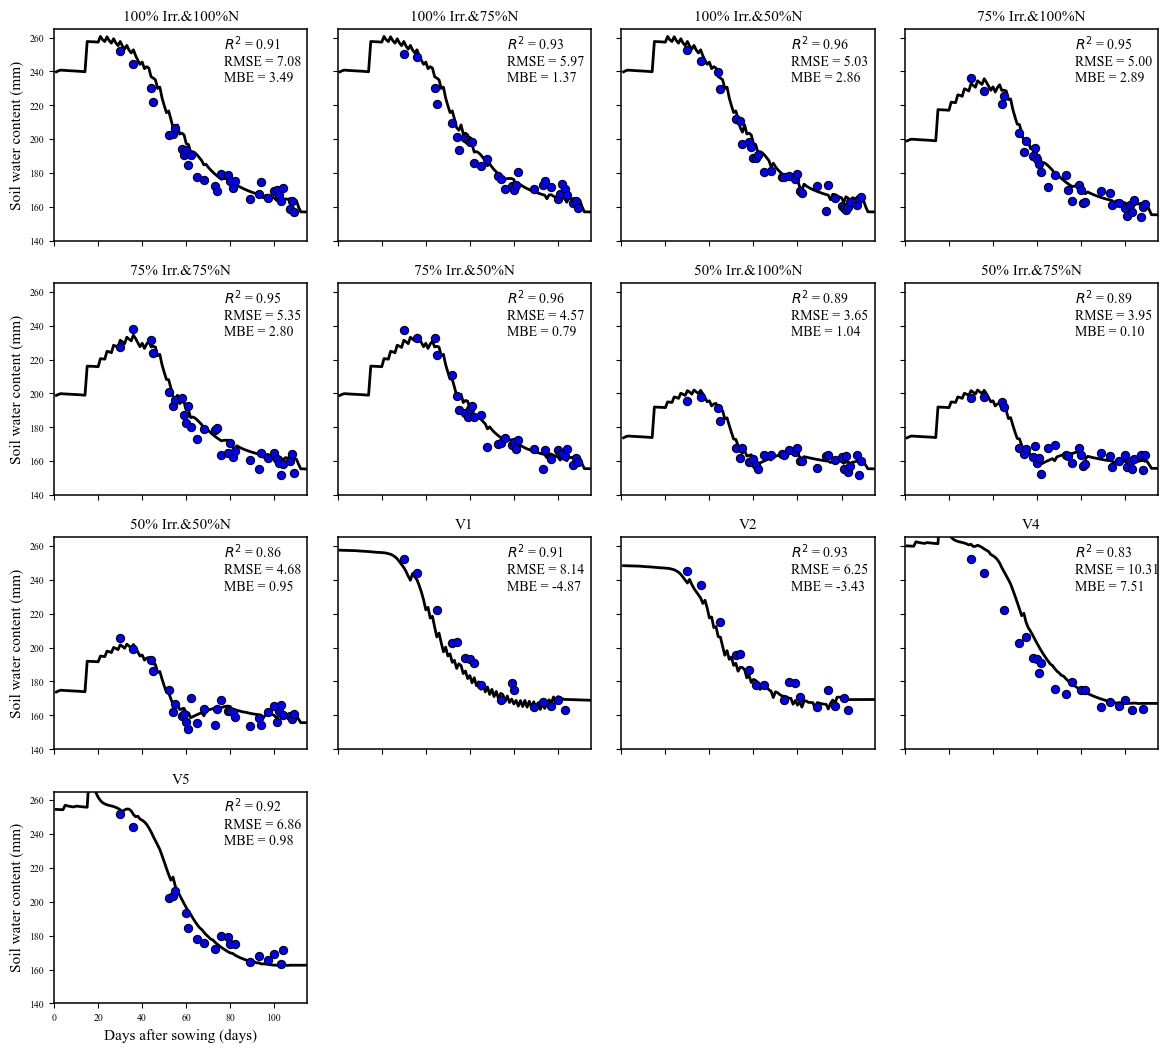

✅ Figure SWC enregistrée : C:\Users\Amine\workspace\morocco_maize\APSIM tout les code et figure\apsim calibration\figure\APSIM_SWC_timeseries_ALL.png


In [ ]:
# -*- coding: utf-8 -*-
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.metrics import r2_score, mean_squared_error

# =====================================================
# STYLE GLOBAL (publication)
# =====================================================
mpl.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "axes.linewidth": 1.1,
})

# =====================================================
# CHEMINS
# =====================================================

SIM_FILE = r"C:\Users\Amine\workspace\morocco_maize\APSIM tout les code et figure\apsim calibration\output_simulation_files\APSIM_simulation_outputs_maize.xlsx"
OBS_FILE = r"C:\Users\Amine\workspace\morocco_maize\APSIM tout les code et figure\apsim calibration\input_calibration\24observed data.xlsx"
OUTPUT_DIR = r"C:\Users\Amine\workspace\morocco_maize\APSIM tout les code et figure\apsim calibration\figure"
# =====================================================
# LABELS DES SCÉNARIOS
# =====================================================
db_labels = {
    "B1_modified.db": "100% Irr.&100%N",
    "B2_modified.db": "100% Irr.&75%N",
    "B3_modified.db": "100% Irr.&50%N",
    "B4_modified.db": "75% Irr.&100%N",
    "B5_modified.db": "75% Irr.&75%N",
    "B6_modified.db": "75% Irr.&50%N",
    "B7_modified.db": "50% Irr.&100%N",
    "B8_modified.db": "50% Irr.&75%N",
    "B9_modified.db": "50% Irr.&50%N",
    "C2_modified.db": "V1",
    "C3_modified.db": "V2",
    "C5_modified.db": "V3",
    "L7_modified.db": "V6",
    "L8_modified.db": "V7",
    "L11_modified.db": "V4",
    "L12_modified.db": "V5"
}

# =====================================================
# STATISTIQUES
# =====================================================
def compute_stats(obs, sim):
    obs = np.array(obs, dtype=float)
    sim = np.array(sim, dtype=float)

    if len(obs) < 2:
        return np.nan, np.nan, np.nan

    r2 = r2_score(obs, sim)
    rmse = np.sqrt(mean_squared_error(obs, sim))
    mbe = np.mean(sim - obs)

    return r2, rmse, mbe

# =====================================================
# FUSION OBS / SIM (POUR STATS SEULEMENT)
# =====================================================
def merge_obs_sim(obs_df, sim_df):
    m = pd.merge(
        obs_df,
        sim_df,
        left_on="Date",
        right_on="Clock.Today.DayOfYear-Maize.SowingDate.DayOfYear+1",
        how="inner"
    )
    return m.dropna(subset=["TotalSWC", "SWC_Observed"])

# =====================================================
# TRACÉ GLOBAL SWC – TIME SERIES
# =====================================================
def plot_all_SWC_timeseries(swc_obs, sim):

    dbs = sorted(swc_obs["DB File"].unique())
    ncols = 4
    nrows = int(np.ceil(len(dbs) / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(12, nrows * 2.8),
        sharex=True, sharey=True
    )
    axes = axes.flatten()

    for i, db in enumerate(dbs):

        obs = swc_obs[swc_obs["DB File"] == db]
        sim_db = sim[sim["DB File"] == db]

        if obs.empty or sim_db.empty:
            continue

        # 🔹 Fusion uniquement pour stats
        m = merge_obs_sim(obs, sim_db)
        if m.empty:
            continue

        ax = axes[i]
        label_db = db_labels.get(db, db)

        # =================================================
        # 🔹 SWC SIMULÉ – TOUTE LA SAISON
        # =================================================
        ax.plot(
            sim_db["Clock.Today.DayOfYear-Maize.SowingDate.DayOfYear+1"],
            sim_db["TotalSWC"],
            color="black",
            linewidth=2
        )

        # =================================================
        # 🔹 SWC OBSERVÉ
        # =================================================
        ax.scatter(
            m["Date"],
            m["SWC_Observed"],
            color="blue",
            edgecolor="black",
            linewidth=0.8,
            s=35,
            zorder=3
        )

        # =================================================
        # 🔹 STATISTIQUES (sans C / V)
        # =================================================
        r2, rmse, mbe = compute_stats(
            m["SWC_Observed"], m["TotalSWC"]
        )

        ax.text(
            0.67, 0.75,
            f"$R^2$ = {r2:.2f}\n"
            f"RMSE = {rmse:.2f}\n"
            f"MBE = {mbe:.2f}",
            transform=ax.transAxes,
            fontsize=10
        )

        # 🔹 TITRE = scénario
        ax.set_title(label_db)

        # 🔹 Limites FIXES
        ax.set_xlim(0, 115)
        ax.set_ylim(140, 265)

        if i % ncols == 0:
            ax.set_ylabel("Soil water content (mm)")

    # =====================================================
    # SUPPRESSION DES AXES VIDES
    # =====================================================
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # 🔹 Axe X uniquement dernière ligne
    for ax in axes[-ncols:]:
        ax.set_xlabel("Days after sowing (days)")

    plt.subplots_adjust(
        wspace=0.12,
        hspace=0.20,
        left=0.06,
        right=0.98,
        top=0.95,
        bottom=0.08
    )

    # =====================================================
    # SAUVEGARDE
    # =====================================================
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    save_path = os.path.join(
        OUTPUT_DIR,
        "APSIM_SWC_timeseries_ALL.png"
    )

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("✅ Figure SWC enregistrée :", save_path)

# =====================================================
# MAIN
# =====================================================
def main():
    sim = pd.read_excel(SIM_FILE)
    swc = pd.read_excel(OBS_FILE, sheet_name="SWC")
    plot_all_SWC_timeseries(swc, sim)

if __name__ == "__main__":
    main()


Above ground dry biomass

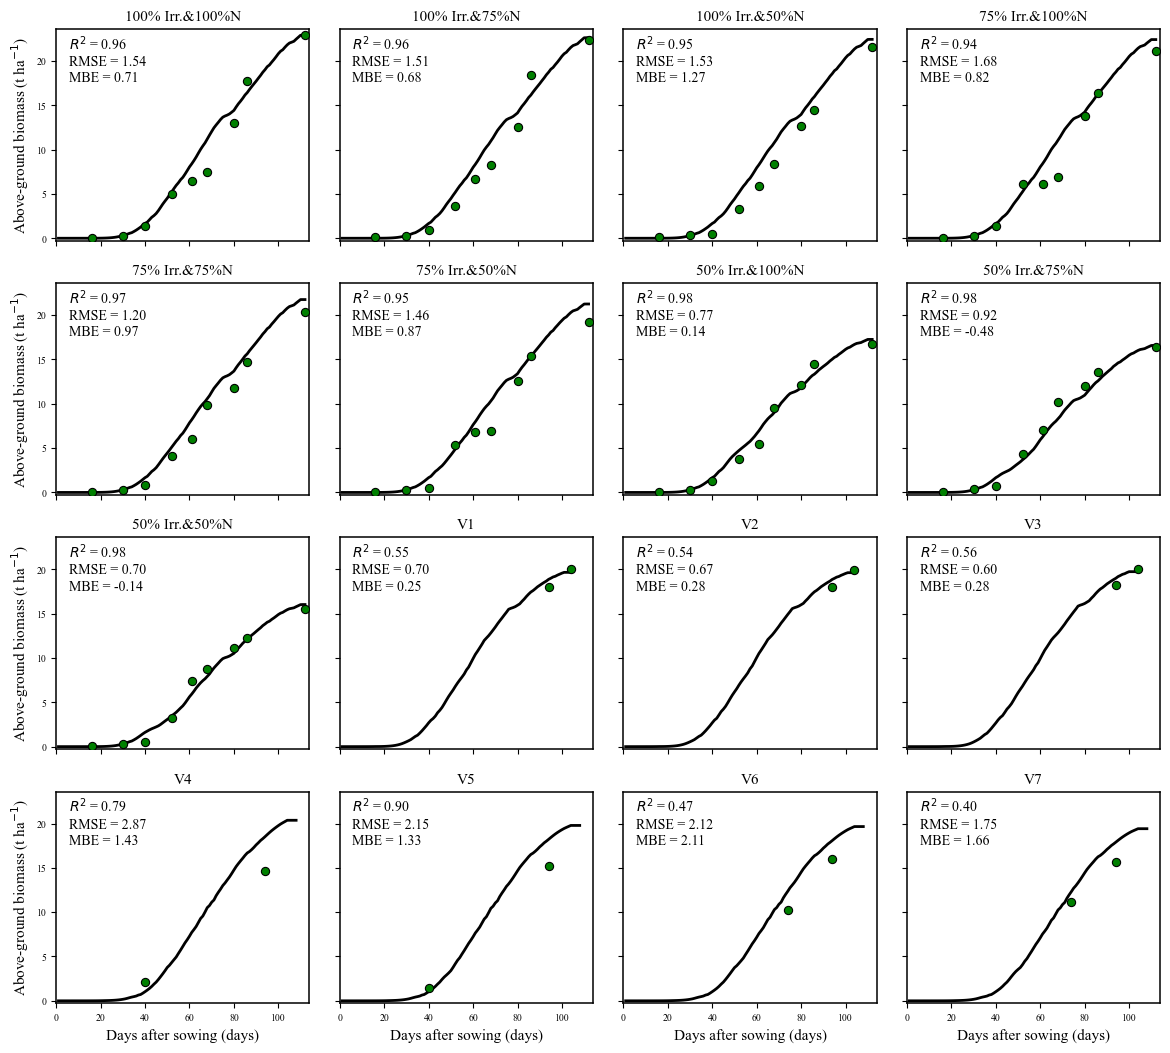

✅ Figure Biomass enregistrée : C:\Users\Amine\workspace\morocco_maize\APSIM tout les code et figure\apsim calibration\figure\APSIM_Biomass_timeseries_ALL.png


In [ ]:
# -*- coding: utf-8 -*-
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.metrics import r2_score, mean_squared_error

# =====================================================
# STYLE GLOBAL (publication)
# =====================================================
mpl.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "axes.linewidth": 1.1,
})

# =====================================================
# CHEMINS
# =====================================================
SIM_FILE = r"C:\Users\Amine\workspace\morocco_maize\APSIM tout les code et figure\apsim calibration\output_simulation_files\APSIM_simulation_outputs_maize.xlsx"
OBS_FILE = r"C:\Users\Amine\workspace\morocco_maize\APSIM tout les code et figure\apsim calibration\input_calibration\24observed data.xlsx"
OUTPUT_DIR = r"C:\Users\Amine\workspace\morocco_maize\APSIM tout les code et figure\apsim calibration\figure"

# =====================================================
# LABELS DES SCÉNARIOS
# =====================================================
db_labels = {
    "B1_modified.db": "100% Irr.&100%N",
    "B2_modified.db": "100% Irr.&75%N",
    "B3_modified.db": "100% Irr.&50%N",
    "B4_modified.db": "75% Irr.&100%N",
    "B5_modified.db": "75% Irr.&75%N",
    "B6_modified.db": "75% Irr.&50%N",
    "B7_modified.db": "50% Irr.&100%N",
    "B8_modified.db": "50% Irr.&75%N",
    "B9_modified.db": "50% Irr.&50%N",
    "C2_modified.db": "V1",
    "C3_modified.db": "V2",
    "C5_modified.db": "V3",
    "L7_modified.db": "V6",
    "L8_modified.db": "V7",
    "L11_modified.db": "V4",
    "L12_modified.db": "V5"
}

# =====================================================
# STATISTIQUES (R² CLASSIQUE)
# =====================================================
def compute_stats(obs, sim):
    obs = np.array(obs, dtype=float)
    sim = np.array(sim, dtype=float)

    if len(obs) < 2:
        return np.nan, np.nan, np.nan

    r2 = r2_score(obs, sim)
    rmse = np.sqrt(mean_squared_error(obs, sim))
    mbe = np.mean(sim - obs)

    return r2, rmse, mbe

# =====================================================
# FUSION OBS / SIM
# =====================================================
def merge_obs_sim(obs_df, sim_df):
    m = pd.merge(
        obs_df,
        sim_df,
        left_on="Date",
        right_on="Clock.Today.DayOfYear-Maize.SowingDate.DayOfYear+1",
        how="inner"
    )
    return m.dropna(subset=["ABGB", "Biomass_Observed"])

# =====================================================
# TRACÉ BIOMASS TIME SERIES
# =====================================================
def plot_all_biomass_timeseries(biom_obs, sim):

    dbs = sorted(biom_obs["DB File"].unique())
    ncols = 4
    nrows = int(np.ceil(len(dbs) / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(12, nrows * 2.8),
        sharex=True, sharey=True
    )
    axes = axes.flatten()

    for i, db in enumerate(dbs):

        obs = biom_obs[biom_obs["DB File"] == db]
        sim_db = sim[sim["DB File"] == db]

        if obs.empty or sim_db.empty:
            continue

        m = merge_obs_sim(obs, sim_db)
        if m.empty:
            continue

        ax = axes[i]
        label_db = db_labels.get(db, db)

        max_date_obs = obs["Date"].max()

        sim_limited = sim_db[
            sim_db["Clock.Today.DayOfYear-Maize.SowingDate.DayOfYear+1"] <= max_date_obs
        ]

        # 🔹 Biomasse simulée
        ax.plot(
            sim_limited["Clock.Today.DayOfYear-Maize.SowingDate.DayOfYear+1"],
            sim_limited["ABGB"],
            color="black",
            linewidth=2
        )

        # 🔹 Biomasse observée
        ax.scatter(
            m["Date"],
            m["Biomass_Observed"],
            color="green",
            edgecolor="black",
            linewidth=0.8,
            s=35,
            zorder=3
        )

        # 🔹 Statistiques (R² harmonisé)
        r2, rmse, mbe = compute_stats(
            m["Biomass_Observed"], m["ABGB"]
        )

        ax.text(
            0.05, 0.75,
            f"$R^2$ = {r2:.2f}\n"
            f"RMSE = {rmse:.2f}\n"
            f"MBE = {mbe:.2f}",
            transform=ax.transAxes,
            fontsize=10
        )

        # 🔹 Titre
        ax.set_title(label_db)

        ax.set_xlim(0, max_date_obs + 4)
        ax.set_ylim(-0.3, 23.6)

        if i % ncols == 0:
            ax.set_ylabel("Above-ground biomass (t ha$^{-1}$)")

    # Suppression axes vides
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Axe X dernière ligne
    for ax in axes[-ncols:]:
        ax.set_xlabel("Days after sowing (days)")

    plt.subplots_adjust(
        wspace=0.12,
        hspace=0.20,
        left=0.06,
        right=0.98,
        top=0.95,
        bottom=0.08
    )

    os.makedirs(OUTPUT_DIR, exist_ok=True)
    save_path = os.path.join(
        OUTPUT_DIR,
        "APSIM_Biomass_timeseries_ALL.png"
    )

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("✅ Figure Biomass enregistrée :", save_path)

# =====================================================
# MAIN
# =====================================================
def main():
    sim = pd.read_excel(SIM_FILE)
    biom = pd.read_excel(OBS_FILE, sheet_name="BM")
    plot_all_biomass_timeseries(biom, sim)

if __name__ == "__main__":
    main()


Residual error 

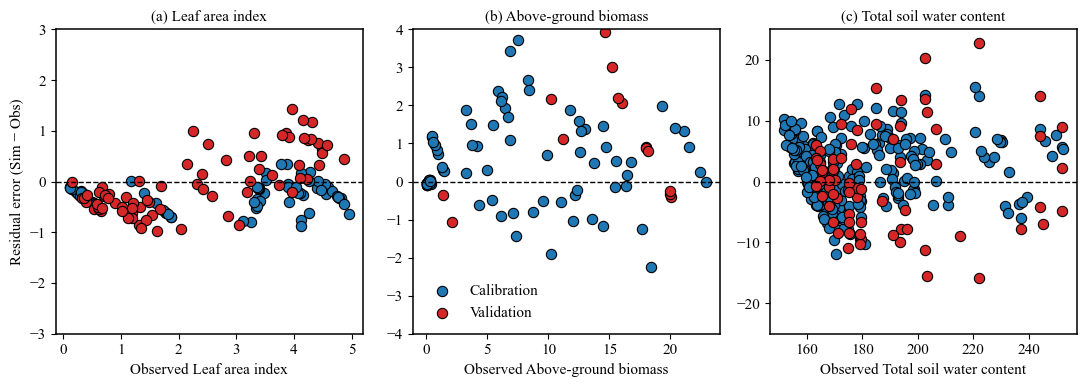

In [ ]:
# -*- coding: utf-8 -*-
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# =====================================================
# STYLE
# =====================================================
mpl.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "axes.linewidth": 1.1,
})

# =====================================================
# PATHS
# =====================================================

SIM_FILE = r"C:\Users\Amine\workspace\morocco_maize\APSIM tout les code et figure\apsim calibration\output_simulation_files\APSIM_simulation_outputs_maize.xlsx"
OBS_FILE = r"C:\Users\Amine\workspace\morocco_maize\APSIM tout les code et figure\apsim calibration\input_calibration\24observed data.xlsx"
SAVE_DIR = r"C:\Users\Amine\workspace\morocco_maize\APSIM tout les code et figure\apsim calibration\figure"
os.makedirs(SAVE_DIR, exist_ok=True)

# =====================================================
# CALIBRATION / VALIDATION
# =====================================================
CAL_FILES = {f"B{i}_modified.db" for i in range(1, 10)}
VAL_FILES = {
    "C2_modified.db", "C3_modified.db", "C5_modified.db",
    "L7_modified.db", "L8_modified.db",
    "L11_modified.db", "L12_modified.db"
}

# =====================================================
# MERGE STRICT SUR DAS
# =====================================================
def merge_on_das(obs_df, sim_df, obs_var, sim_var):

    obs = obs_df.copy()
    sim = sim_df.copy()

    obs["DAS"] = pd.to_numeric(obs["Date"], errors="coerce")
    sim["DAS"] = pd.to_numeric(
        sim["Clock.Today.DayOfYear-Maize.SowingDate.DayOfYear+1"],
        errors="coerce"
    )

    m = pd.merge(
        obs,
        sim,
        on=["DB File", "DAS"],
        how="inner"
    )

    m["Residual"] = m[sim_var] - m[obs_var]
    return m.dropna(subset=["Residual"])

# =====================================================
# FIGURE RESIDUALS (3 PANELS)
# =====================================================
def plot_residuals_3panels(df_lai, df_bm, df_swc):

    fig, axes = plt.subplots(1, 3, figsize=(11, 4))

    panels = [
        ("(a) Leaf area index", df_lai, "LAI", (-3, 3)),
        ("(b) Above-ground biomass", df_bm, "Biomass_Observed", (-4, 4)),
        ("(c) Total soil water content", df_swc, "SWC_Observed", (-25, 25)),
    ]

    for ax, (title, df, obs_col, ylim) in zip(axes, panels):

        cal = df[df["DB File"].isin(CAL_FILES)]
        val = df[df["DB File"].isin(VAL_FILES)]

        ax.scatter(
            cal[obs_col], cal["Residual"],
            s=55, facecolor="#1f77b4",
            edgecolor="black", linewidth=0.8,
            label="Calibration"
        )

        ax.scatter(
            val[obs_col], val["Residual"],
            s=55, facecolor="#d62728",
            edgecolor="black", linewidth=0.8,
            label="Validation"
        )

        ax.axhline(0, color="black", linestyle="--", linewidth=1)
        ax.set_title(title)
        ax.set_xlabel(f"Observed {title.split(') ')[1]}")
        ax.set_ylim(ylim)
        ax.grid(False)

    axes[0].set_ylabel("Residual error (Sim − Obs)")
    axes[1].legend(frameon=False)

    plt.tight_layout()
    plt.savefig(
        os.path.join(SAVE_DIR, "APSIM_Residuals_LAI_BM_SWC_checked.png"),
        dpi=300, bbox_inches="tight"
    )
    plt.show()

# =====================================================
# MAIN
# =====================================================
def main():

    sim = pd.read_excel(SIM_FILE)

    obs_lai = pd.read_excel(OBS_FILE, sheet_name="LAI")
    obs_bm  = pd.read_excel(OBS_FILE, sheet_name="BM")
    obs_swc = pd.read_excel(OBS_FILE, sheet_name="SWC")

    # --- Merge strict DAS ---
    df_lai = merge_on_das(obs_lai, sim, "LAI", "Maize.Leaf.LAI")
    df_bm  = merge_on_das(obs_bm,  sim, "Biomass_Observed", "ABGB")
    df_swc = merge_on_das(obs_swc, sim, "SWC_Observed", "TotalSWC")

    plot_residuals_3panels(df_lai, df_bm, df_swc)

# =====================================================
# RUN
# =====================================================
if __name__ == "__main__":
    main()

Soil & Maize Nitogen

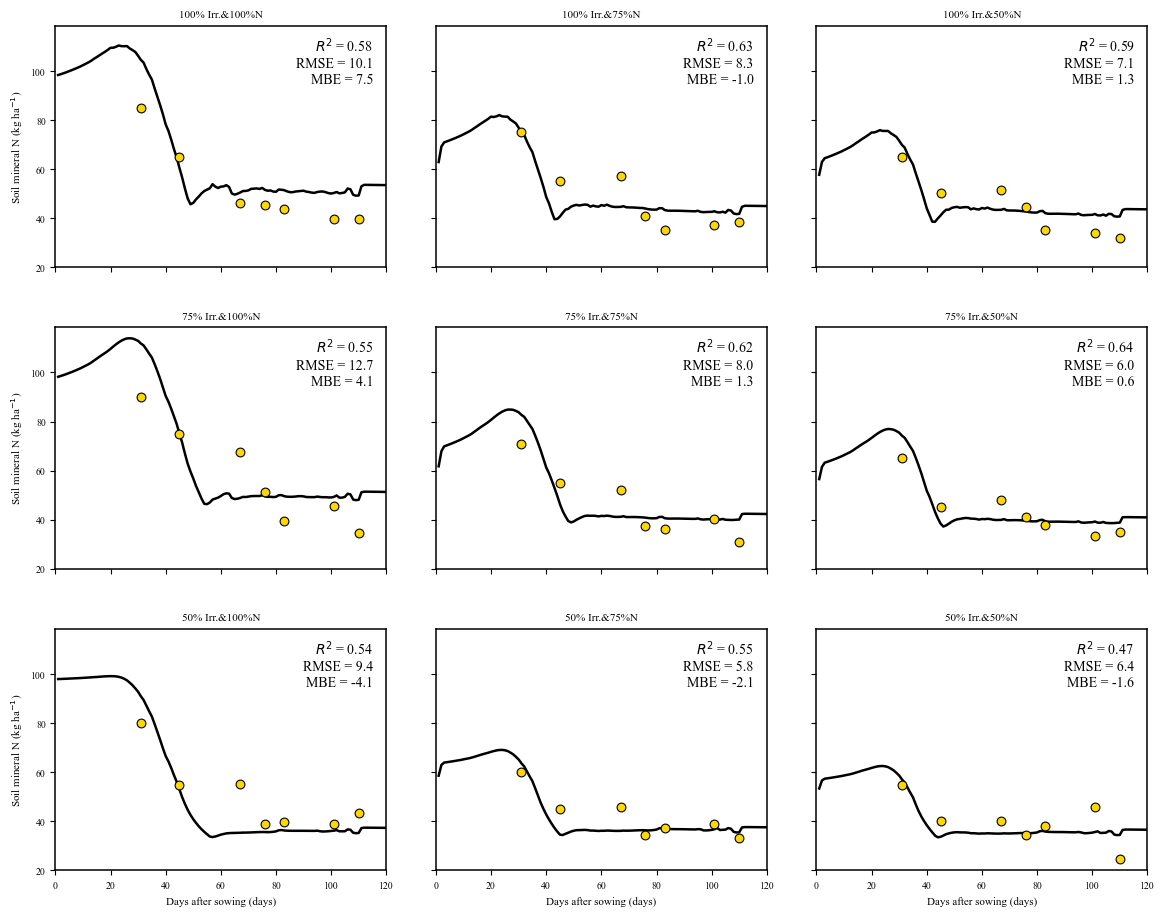

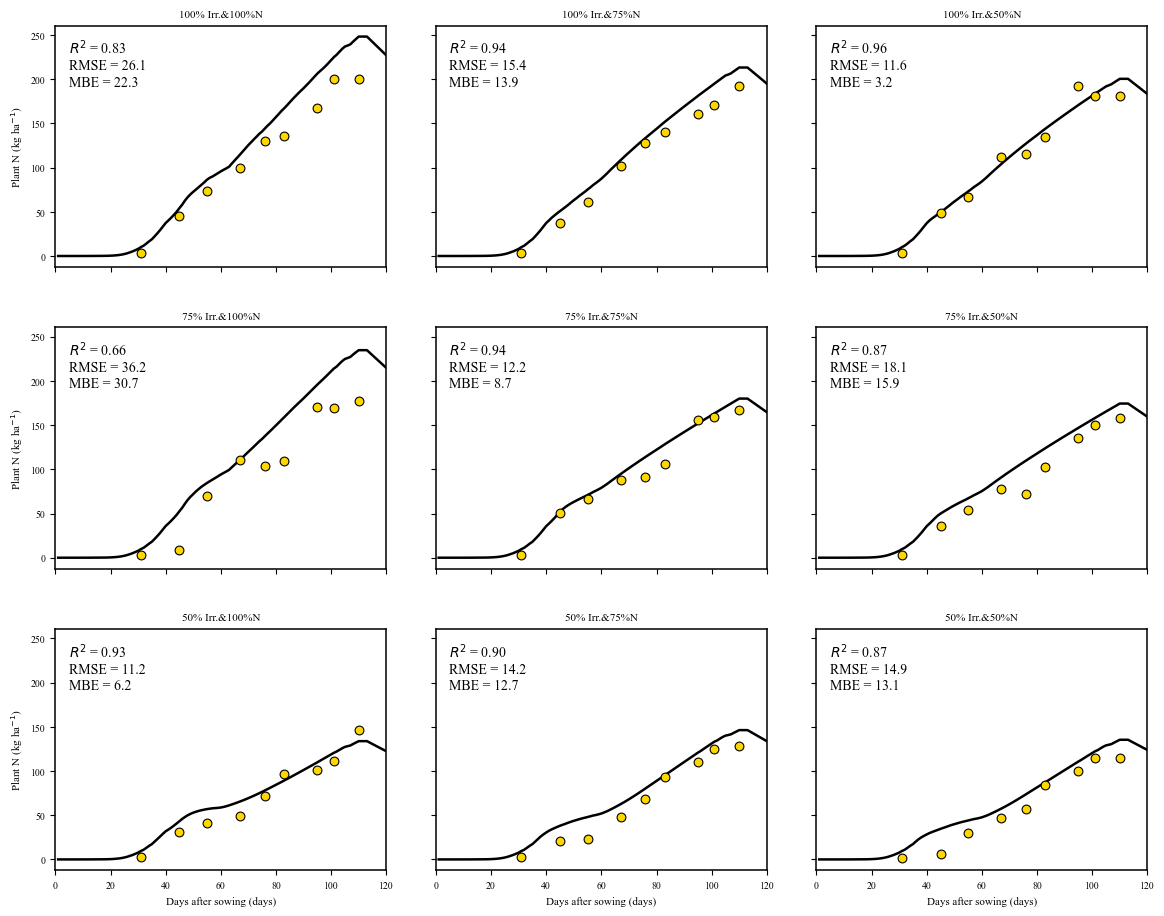

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import math

# ============================================================
# CHEMINS
# ============================================================

sim_excel = r"C:\Users\Amine\workspace\morocco_maize\APSIM tout les code et figure\apsim calibration\output_simulation_files\APSIM_simulation_outputs_maize.xlsx"
obs_excel = r"C:\Users\Amine\workspace\morocco_maize\APSIM tout les code et figure\apsim calibration\input_calibration\observed_nitrogen_data.xlsx"
output_dir = r"C:\Users\Amine\workspace\morocco_maize\APSIM tout les code et figure\apsim calibration\figure"

os.makedirs(output_dir, exist_ok=True)

# ============================================================
# STYLE ACADEMIQUE
# ============================================================
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 11,
    "axes.linewidth": 1.1
})

# ============================================================
# LABELS DES PARCELLES
# ============================================================
db_labels = {
    "B1": "100% Irr.&100%N",
    "B2": "100% Irr.&75%N",
    "B3": "100% Irr.&50%N",
    "B4": "75% Irr.&100%N",
    "B5": "75% Irr.&75%N",
    "B6": "75% Irr.&50%N",
    "B7": "50% Irr.&100%N",
    "B8": "50% Irr.&75%N",
    "B9": "50% Irr.&50%N",
}

parcelles = list(db_labels.keys())

# ============================================================
# LECTURE DES DONNEES
# ============================================================
df_report = pd.read_excel(sim_excel)
df_obs_soil = pd.read_excel(obs_excel, sheet_name="Feuil1")
df_obs_plant = pd.read_excel(obs_excel, sheet_name="F2")

# ============================================================
# VERIFICATION DES COLONNES
# ============================================================
required_sim_cols = {
    "DB File",
    "Clock.Today",
    "Clock.Today.DayOfYear-Maize.SowingDate.DayOfYear+1",
    "MineralN",
    "MaizeN"
}
missing_sim = required_sim_cols - set(df_report.columns)
if missing_sim:
    raise ValueError(f"Colonnes manquantes dans le fichier simulé: {missing_sim}")

required_soil_cols = {"Clock.Today", "observedMineralN"}
required_plant_cols = {"Clock.Today", "observedMaizeN"}

missing_soil = required_soil_cols - set(df_obs_soil.columns)
missing_plant = required_plant_cols - set(df_obs_plant.columns)

if missing_soil:
    raise ValueError(f"Colonnes manquantes dans Feuil1: {missing_soil}")
if missing_plant:
    raise ValueError(f"Colonnes manquantes dans F2: {missing_plant}")

# ============================================================
# FONCTIONS UTILES
# ============================================================
def normalize_parcel_name(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    x = x.replace(".db", "")
    x = x.replace("_modified", "")
    return x


def build_parcel_key_from_obs(df_obs):
    df_obs = df_obs.copy()

    if "SimulationName" in df_obs.columns:
        df_obs["ParcelKey"] = df_obs["SimulationName"].apply(normalize_parcel_name)
    elif "DB File" in df_obs.columns:
        df_obs["ParcelKey"] = df_obs["DB File"].apply(normalize_parcel_name)
    else:
        raise ValueError(
            "Le fichier observé doit contenir 'SimulationName' ou 'DB File'."
        )

    return df_obs


def build_parcel_key_from_sim(df_sim):
    df_sim = df_sim.copy()
    df_sim["ParcelKey"] = df_sim["DB File"].apply(normalize_parcel_name)
    return df_sim

# ============================================================
# PREPARATION DES DONNEES
# ============================================================
df_report = build_parcel_key_from_sim(df_report)
df_obs_soil = build_parcel_key_from_obs(df_obs_soil)
df_obs_plant = build_parcel_key_from_obs(df_obs_plant)

# Dates normalisées au jour
for df in [df_report, df_obs_soil, df_obs_plant]:
    df["Clock.Today"] = pd.to_datetime(
        df["Clock.Today"], dayfirst=True, errors="coerce"
    ).dt.normalize()

# Colonnes numériques
das_col = "Clock.Today.DayOfYear-Maize.SowingDate.DayOfYear+1"
soil_sim, soil_obs = "MineralN", "observedMineralN"
plant_sim, plant_obs = "MaizeN", "observedMaizeN"

df_report[das_col] = pd.to_numeric(df_report[das_col], errors="coerce")
df_report[soil_sim] = pd.to_numeric(df_report[soil_sim], errors="coerce")
df_report[plant_sim] = pd.to_numeric(df_report[plant_sim], errors="coerce")
df_obs_soil[soil_obs] = pd.to_numeric(df_obs_soil[soil_obs], errors="coerce")
df_obs_plant[plant_obs] = pd.to_numeric(df_obs_plant[plant_obs], errors="coerce")

# ============================================================
# STATS (R² MODELE)
# ============================================================
def calc_stats(sim, obs):
    sim = np.asarray(sim, dtype=float)
    obs = np.asarray(obs, dtype=float)

    mask = np.isfinite(sim) & np.isfinite(obs)
    sim = sim[mask]
    obs = obs[mask]

    if len(sim) < 2:
        return np.nan, np.nan, np.nan

    rmse = np.sqrt(np.mean((sim - obs) ** 2))
    mbe = np.mean(sim - obs)

    ss_res = np.sum((obs - sim) ** 2)
    ss_tot = np.sum((obs - np.mean(obs)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

    return r2, rmse, mbe


def stats_text(r2, rmse, mbe, n):
    if n < 2:
        return f"n = {n}\n$R^2$ = NA\nRMSE = NA\nMBE = NA"
    return f"$R^2$ = {r2:.2f}\nRMSE = {rmse:.1f}\nMBE = {mbe:.1f}"

# ============================================================
# FIGURE SERIES TEMPORELLES
# ============================================================
def plot_timeseries(sim_col, obs_df, obs_col, ylabel, filename, stats_store):

    ncols = 3
    nrows = math.ceil(len(parcelles) / ncols)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(12, nrows * 3.2),
        sharex=True, sharey=True
    )
    axes = np.array(axes).flatten()

    for i, parcelle in enumerate(parcelles):
        ax = axes[i]

        # ---- simulé
        sim = (
            df_report[df_report["ParcelKey"] == parcelle]
            .dropna(subset=[das_col, sim_col])
            .sort_values(das_col)
            .copy()
        )

        if not sim.empty:
            ax.plot(
                sim[das_col], sim[sim_col],
                color="black", linewidth=1.8
            )

        # ---- observé
        obs = (
            obs_df[obs_df["ParcelKey"] == parcelle]
            .dropna(subset=["Clock.Today", obs_col])
            .copy()
        )

        # Pour placer les points observés sur l'axe DAS,
        # on récupère le DAS simulé à la même date
        merged = obs.merge(
            sim[["ParcelKey", "Clock.Today", das_col, sim_col]],
            on=["ParcelKey", "Clock.Today"],
            how="inner"
        ).sort_values(das_col)

        ax.scatter(
            merged[das_col],
            merged[obs_col],
            s=40,
            facecolor="#FFD700",
            edgecolor="black",
            linewidth=0.8,
            zorder=3
        )

        # ---- stats
        r2, rmse, mbe = calc_stats(merged[sim_col], merged[obs_col])
        stats_store.append([parcelle, r2, rmse, mbe, len(merged)])

        txt = stats_text(r2, rmse, mbe, len(merged))

        if sim_col == soil_sim:
            ax.text(
                0.96, 0.96, txt,
                transform=ax.transAxes,
                ha="right", va="top",
                fontsize=10
            )
        else:
            ax.text(
                0.04, 0.75, txt,
                transform=ax.transAxes,
                fontsize=10
            )

        ax.set_title(db_labels[parcelle])
        ax.set_xlim(0, 120)
        ax.grid(False)

        if i % ncols == 0:
            ax.set_ylabel(ylabel)

    # ---- suppression axes vides
    for j in range(len(parcelles), len(axes)):
        fig.delaxes(axes[j])

    # ---- label X dernière ligne utile
    start_last_row = max(0, len(parcelles) - ncols)
    for k in range(start_last_row, len(parcelles)):
        axes[k].set_xlabel("Days after sowing (days)")

    plt.subplots_adjust(
        wspace=0.15,
        hspace=0.25,
        left=0.07,
        right=0.98,
        top=0.96,
        bottom=0.08
    )

    save_path = os.path.join(output_dir, filename)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    # print(f"✅ Figure enregistrée : {save_path}")

# ============================================================
# EXECUTION FIGURES + STATS
# ============================================================
soil_stats = []
plant_stats = []

plot_timeseries(
    soil_sim, df_obs_soil, soil_obs,
    "Soil mineral N (kg ha$^{-1}$)",
    "SoilN_timeseries_9_subplots.png",
    soil_stats
)

plot_timeseries(
    plant_sim, df_obs_plant, plant_obs,
    "Plant N (kg ha$^{-1}$)",
    "MaizeN_timeseries_9_subplots.png",
    plant_stats
)